# Calories Burnt Prediction - Detailed EDA & Insights

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for plots
sns.set_theme(style="whitegrid")

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


## 1. Loading the Dataset

In [4]:
df = pd.read_csv('calories.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


## 2. Feature Engineering

In [5]:
# 1. Create BMI (Body Mass Index)
# BMI = weight(kg) / [height(m)]^2
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

# 2. Interaction Features
# Intensity Score = Heart_Rate * Duration
df['Intensity_Score'] = df['Heart_Rate'] * df['Duration']

# Metabolic Stress = Body_Temp * Heart_Rate
df['Metabolic_Stress'] = df['Body_Temp'] * df['Heart_Rate']

print("New features created: BMI, Intensity_Score, Metabolic_Stress")
df[['BMI', 'Intensity_Score', 'Metabolic_Stress']].head()

New features created: BMI, Intensity_Score, Metabolic_Stress


,BMI,Intensity_Score,Metabolic_Stress
0,26.038781,3045.0,4284.0
1,21.773842,1316.0,3788.2
2,24.655910,440.0,3405.6
3,22.159109,1300.0,4050.0
4,24.456063,810.0,3223.8


## 3. Encoding Categorical Features

In [6]:
# Label Encoding for Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print(f"Encoded Gender: {dict(zip(le.classes_, le.transform(le.classes_)))}")
df.head()

Encoded Gender: {'female': np.int64(0), 'male': np.int64(1)}


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Intensity_Score,Metabolic_Stress
0,14733363,1,68,190.0,94.0,29.0,105.0,40.8,231.0,26.038781,3045.0,4284.0
1,14861698,0,20,166.0,60.0,14.0,94.0,40.3,66.0,21.773842,1316.0,3788.2
2,11179863,1,69,179.0,79.0,5.0,88.0,38.7,26.0,24.655910,440.0,3405.6
3,16180408,0,34,179.0,71.0,13.0,100.0,40.5,71.0,22.159109,1300.0,4050.0
4,17771927,0,27,154.0,58.0,10.0,81.0,39.8,35.0,24.456063,810.0,3223.8


## 4. Scaling Numerical Features

In [7]:
# Define features to scale
features_to_scale = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'BMI', 'Intensity_Score', 'Metabolic_Stress']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Numerical features scaled using StandardScaler.")
df_scaled.head()

Numerical features scaled using StandardScaler.


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Intensity_Score,Metabolic_Stress
0,14733363,1,1.484726,1.089582,1.265909,1.619127,0.989404,0.994023,231.0,1.086705,1.610215,1.030418
1,14861698,0,-1.342179,-0.593726,-0.995458,-0.183990,-0.158461,0.352342,66.0,-1.649455,-0.253843,-0.092234
2,11179863,1,1.543620,0.318066,0.268247,-1.265861,-0.784569,-1.701035,26.0,0.199528,-1.198270,-0.958565
3,16180408,0,-0.517665,0.318066,-0.263839,-0.304198,0.467647,0.609015,71.0,-1.402288,-0.271093,0.500566
4,17771927,0,-0.929922,-1.435380,-1.128480,-0.664821,-1.515029,-0.289338,35.0,0.071317,-0.799368,-1.370220


## 5. Model Training and Evaluation

In [ ]:
# 1. Define X and y
X = df_scaled.drop(['User_ID', 'Calories', 'Age'], axis=1)
y = df_scaled['Calories']

# 2. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# 3. Model Training
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Model': name, 'RMSE': rmse, 'R2 Score': r2})

# 4. Display results in a table
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print("\n--- Model Performance Comparison ---")
print(results_df.to_string(index=False))

# 5. Best Model Identification
best_model_name = results_df.iloc[0]['Model']
print(f"\nBest Model: {best_model_name}")

X_train shape: (12000, 9), X_test shape: (3000, 9)


## 6. Hyperparameter Tuning for XGBoost

In [ ]:
# 1. Define hyperparameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb = XGBRegressor(random_state=42)

# 2. Perform Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_grid, 
    n_iter=10, 
    scoring='neg_mean_squared_error', 
    cv=3, 
    verbose=1, 
    random_state=42, 
    n_jobs=-1
)

print("--- Starting Hyperparameter Tuning (RandomizedSearchCV) ---")
random_search.fit(X_train, y_train)

# 3. Best Model Evaluation
best_xgb = random_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

# 4. Before vs After Comparison
comparison_data = {
    'Metric': ['RMSE', 'R2 Score'],
    'Base XGBoost': [results_df[results_df['Model'] == 'XGBoost']['RMSE'].values[0], 
                     results_df[results_df['Model'] == 'XGBoost']['R2 Score'].values[0]],
    'Tuned XGBoost': [rmse_tuned, r2_tuned]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n--- Before vs After Tuning Comparison ---")
print(comparison_df.to_string(index=False))

print(f"\nBest Parameters found: {random_search.best_params_}")

## 7. Interactive Visualizations with Plotly

In [ ]:
# Sample data for faster interactive rendering
df_sample = df.sample(2000, random_state=42)

# 1. Calories vs Duration (Interactive)
fig1 = px.scatter(df_sample, x='Duration', y='Calories', color='Gender', 
                 title='Interactive: Calories vs Duration', 
                 labels={'Gender': '0:Female, 1:Male'},
                 template='plotly_white', opacity=0.7, trendline='ols')
fig1.show()

# 2. Heart Rate vs Calories (Interactive)
fig2 = px.scatter(df_sample, x='Heart_Rate', y='Calories', color='Duration', 
                 title='Interactive: Heart Rate vs Calories', 
                 template='plotly_white', opacity=0.7)
fig2.show()

# 3. Feature Importance (Interactive)
importance = best_xgb.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance}).sort_values(by='Importance', ascending=True)

fig3 = px.bar(importance_df, x='Importance', y='Feature', orientation='h', 
             title='Interactive: Feature Importance (Tuned XGBoost)',
             color='Importance', color_continuous_scale='Viridis')
fig3.show()

# 4. Prediction vs Actual Graph (Interactive)
comparison_plot_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_tuned}).sample(500, random_state=42)

fig4 = go.Figure()
fig4.add_trace(go.Scatter(x=comparison_plot_df['Actual'], y=comparison_plot_df['Predicted'], 
                         mode='markers', name='Predictions', 
                         marker=dict(color='blue', opacity=0.6)))
fig4.add_trace(go.Scatter(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], 
                         mode='lines', name='Perfect Prediction', 
                         line=dict(color='red', dash='dash')))

fig4.update_layout(title='Interactive: Predicted vs Actual Calories',
                  xaxis_title='Actual Calories',
                  yaxis_title='Predicted Calories',
                  template='plotly_white')
fig4.show()

## 8. Export Model and Scaler for Streamlit App

In [ ]:
# Save the best tuned XGBoost model
joblib.dump(best_xgb, 'best_xgb_model.pkl')

# Save the scaler for scaling new inputs in the app
joblib.dump(scaler, 'scaler.pkl')

# Save the label encoder for gender mapping
joblib.dump(le, 'label_encoder.pkl')

print("Model, Scaler, and Label Encoder saved successfully for the Streamlit app!")

## 9. Basic Data Exploration

In [ ]:
print("--- Basic Information ---")
df.info()

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows Check ---")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n--- Statistical Summary ---")
df.describe()

## 3. Outlier Detection

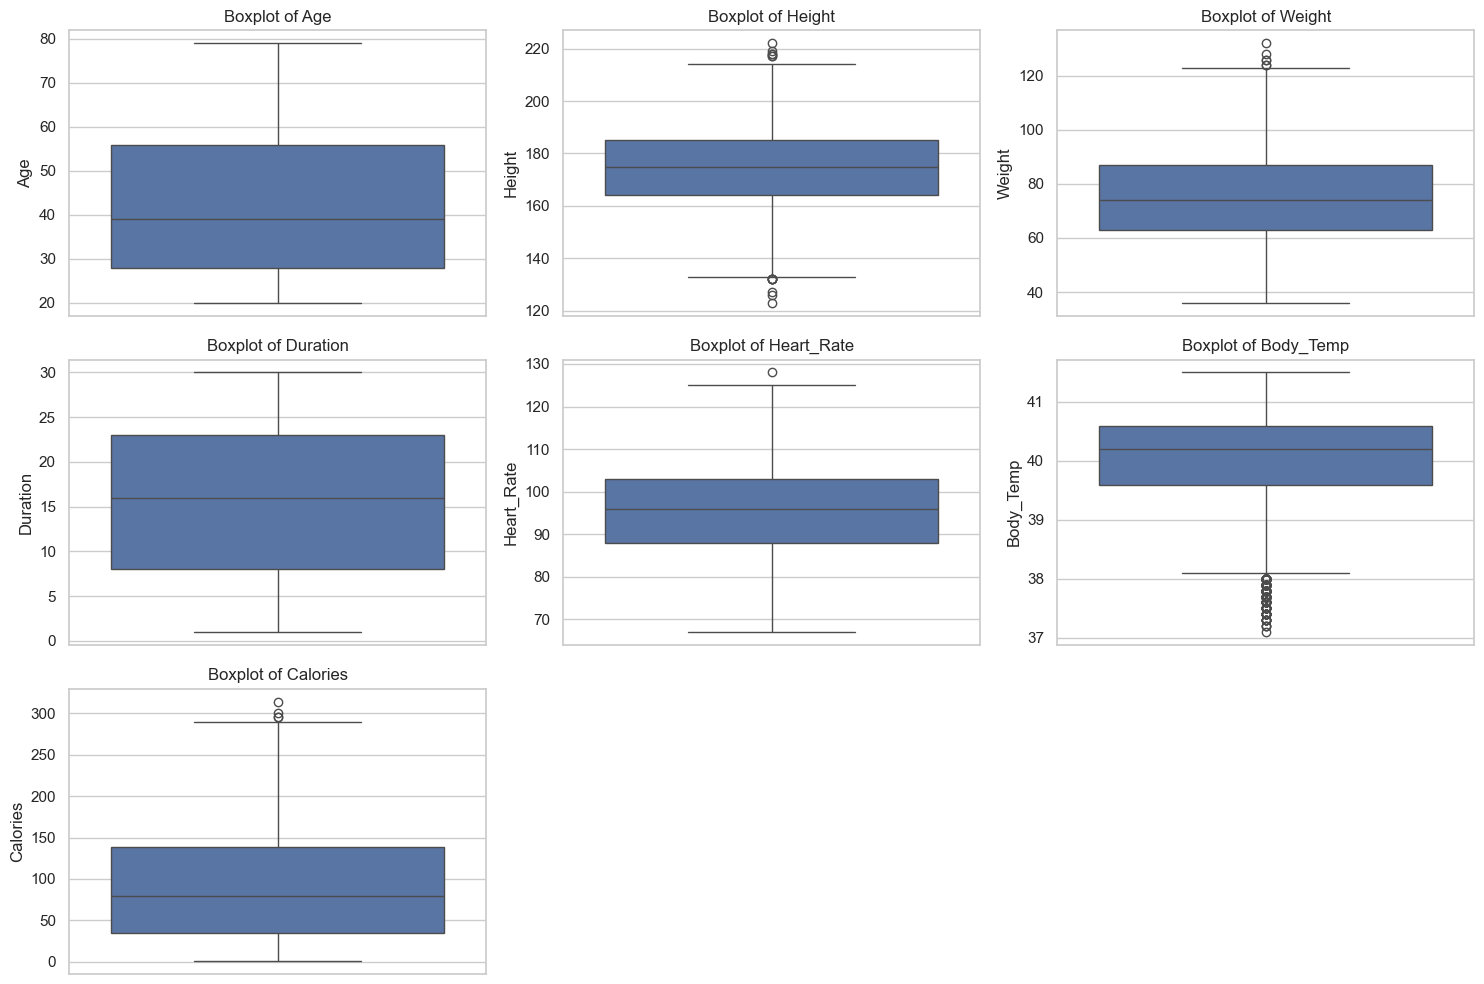

In [9]:
num_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## 4. Outlier Treatment (Capping using IQR)

In [10]:
def treat_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f"Treating {outliers_count} outliers in {column}...")
    
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

df_cleaned = df.copy()
for col in num_cols:
    df_cleaned = treat_outliers(df_cleaned, col)

print("\nOutlier treatment complete.")

Treating 0 outliers in Age...
Treating 14 outliers in Height...
Treating 6 outliers in Weight...
Treating 0 outliers in Duration...
Treating 1 outliers in Heart_Rate...
Treating 369 outliers in Body_Temp...
Treating 4 outliers in Calories...

Outlier treatment complete.


## 5. Feature Distributions

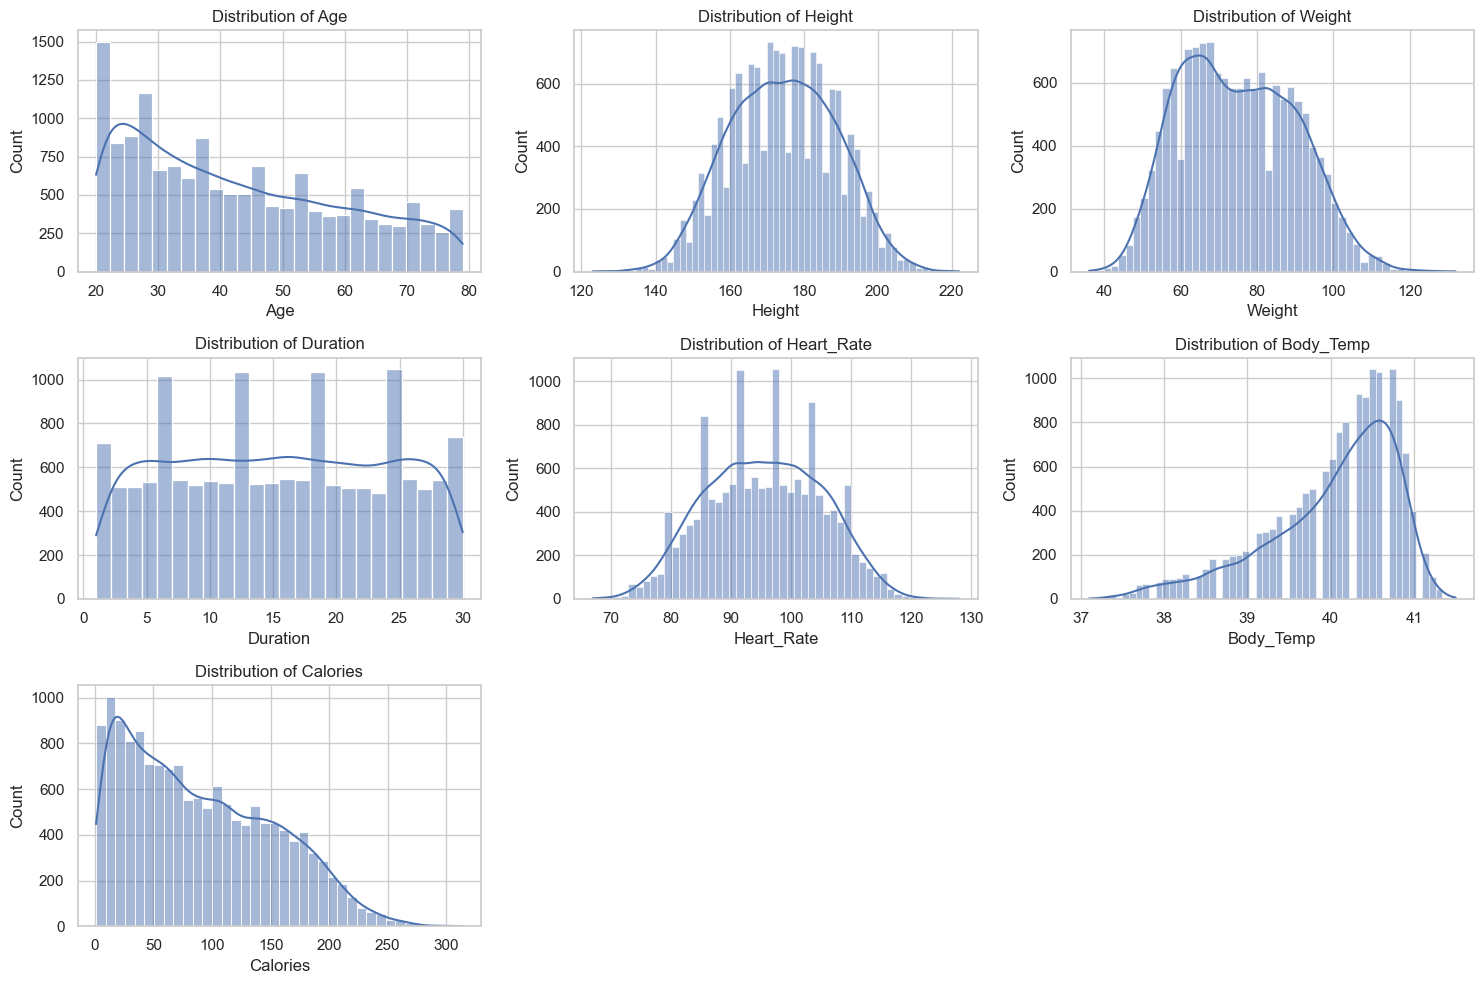

In [11]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

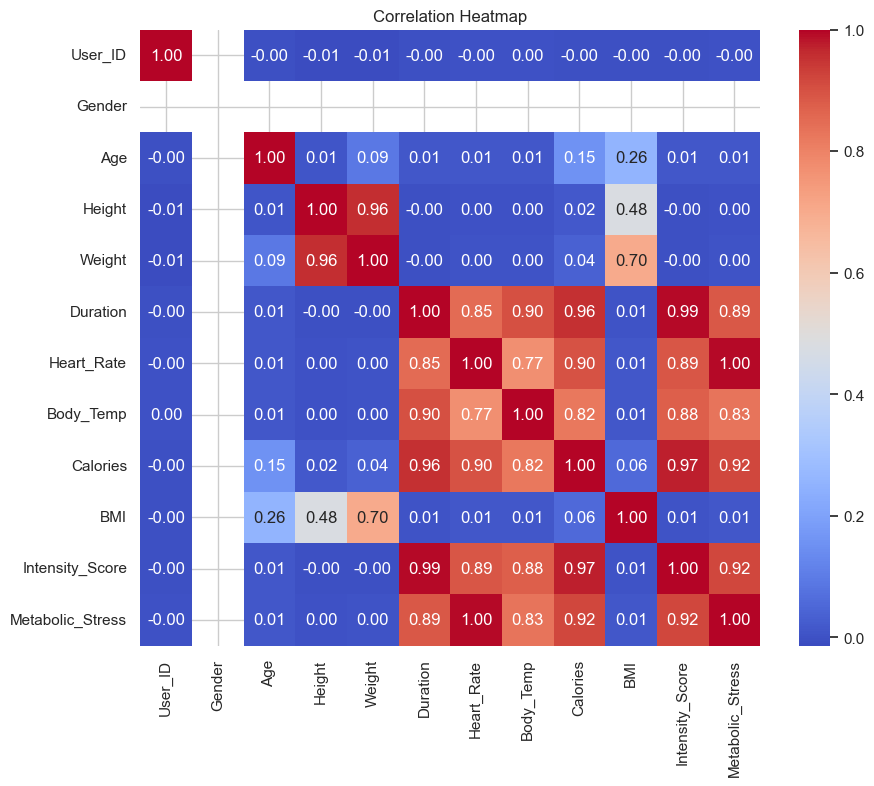

In [12]:
df_corr = df.copy()
df_corr['Gender'] = df_corr['Gender'].map({'male': 0, 'female': 1})

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 7. Relationship Analysis

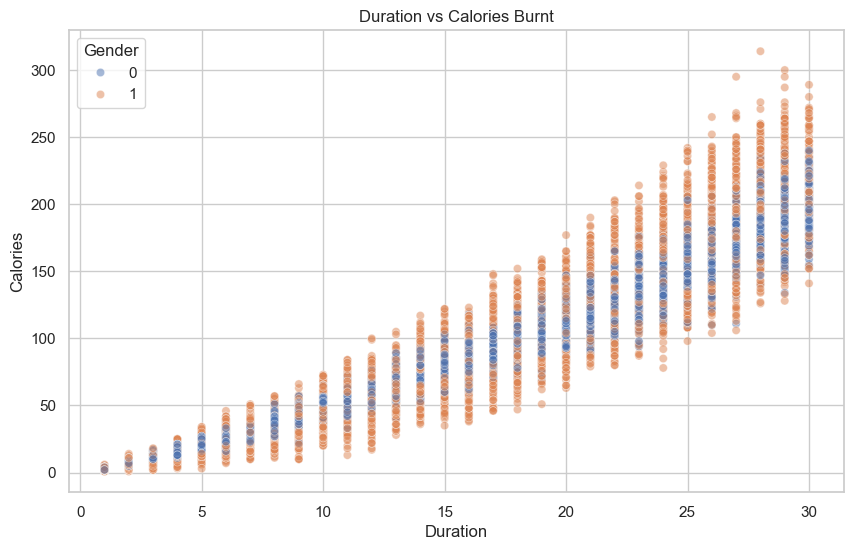

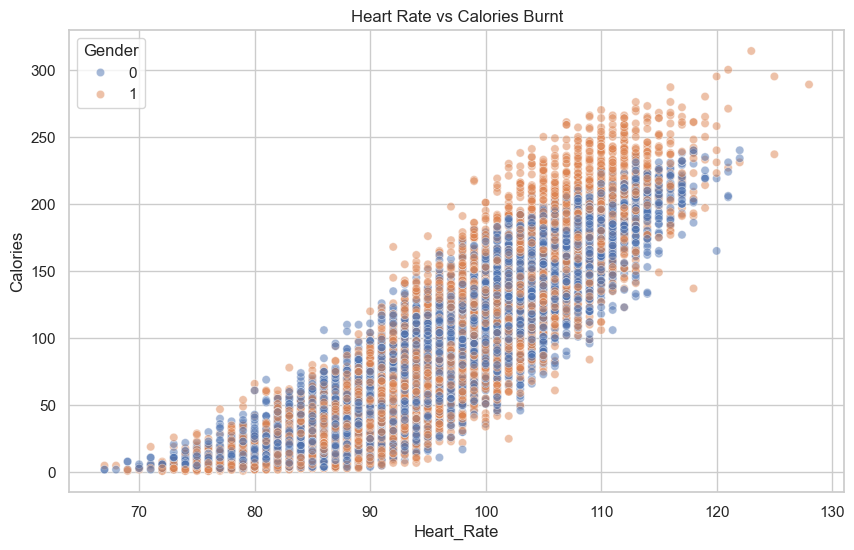

In [13]:
# Duration vs Calories
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Duration', y='Calories', hue='Gender', alpha=0.5)
plt.title('Duration vs Calories Burnt')
plt.show()

# Heart Rate vs Calories
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Heart_Rate', y='Calories', hue='Gender', alpha=0.5)
plt.title('Heart Rate vs Calories Burnt')
plt.show()

## 8. Key Insights

In [14]:
print("--- Key Insights ---")

# Gender distribution
print("\nGender Distribution:")
print(df['Gender'].value_counts())

# Average Calories by Gender
print("\nAverage Calories Burnt by Gender:")
print(df.groupby('Gender')['Calories'].mean())

# Age Group Analysis
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young (0-30)', 'Middle-Aged (31-50)', 'Senior (51+)'])
print("\nAverage Calories Burnt by Age Group:")
print(df.groupby('AgeGroup')['Calories'].mean())

# Body Temp vs Calories
print("\nAverage Calories Burnt by Body Temp Range:")
print(df.groupby(pd.cut(df['Body_Temp'], bins=5))['Calories'].mean())

--- Key Insights ---

Gender Distribution:
Gender
0    7553
1    7447
Name: count, dtype: int64

Average Calories Burnt by Gender:
Gender
0    88.153052
1    90.945750
Name: Calories, dtype: float64

Average Calories Burnt by Age Group:
AgeGroup
Young (0-30)            79.224745
Middle-Aged (31-50)     87.956329
Senior (51+)           101.242834
Name: Calories, dtype: float64

Average Calories Burnt by Body Temp Range:
Body_Temp
(37.096, 37.98]      4.466192
(37.98, 38.86]      10.780136
(38.86, 39.74]      30.077718
(39.74, 40.62]      94.672330
(40.62, 41.5]      166.306960
Name: Calories, dtype: float64
